## Fixed cells so much junk in there i want to filter out the detritus

In [23]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/jatafixed/merged")
file_pattern = "*.csv"

min_roi_area = 1000       # change as needed
max_roi_area = 10_000   # change as needed

# -----------------------------
# Compile filtered data
# -----------------------------
compiled_dfs = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    required_cols = ["RoiHeight", "RoiWidth"]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"Skipping {file.name}: missing columns {missing_cols}")
        continue

    df["RoiArea"] = df["RoiHeight"] * df["RoiWidth"]

    df_filtered = df[
        (df["RoiArea"] >= min_roi_area) &
        (df["RoiArea"] <= max_roi_area)
    ].copy()

    df_filtered["source_file"] = file.name

    compiled_dfs.append(df_filtered)

if compiled_dfs:
    compiled_df = pd.concat(compiled_dfs, ignore_index=True)
else:
    compiled_df = pd.DataFrame()

print(f"Compiled dataframe shape: {compiled_df.shape}")

Compiled dataframe shape: (96514, 15)


Text(0, 0.5, 'Frequency')

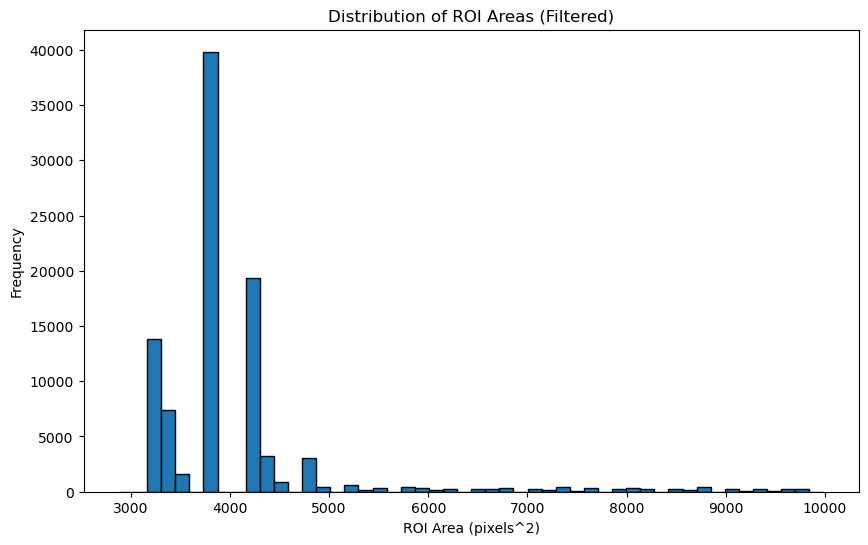

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(compiled_df["RoiArea"], bins=50, edgecolor='black')
plt.title("Distribution of ROI Areas (Filtered)")
plt.xlabel("ROI Area (pixels^2)")
plt.ylabel("Frequency")

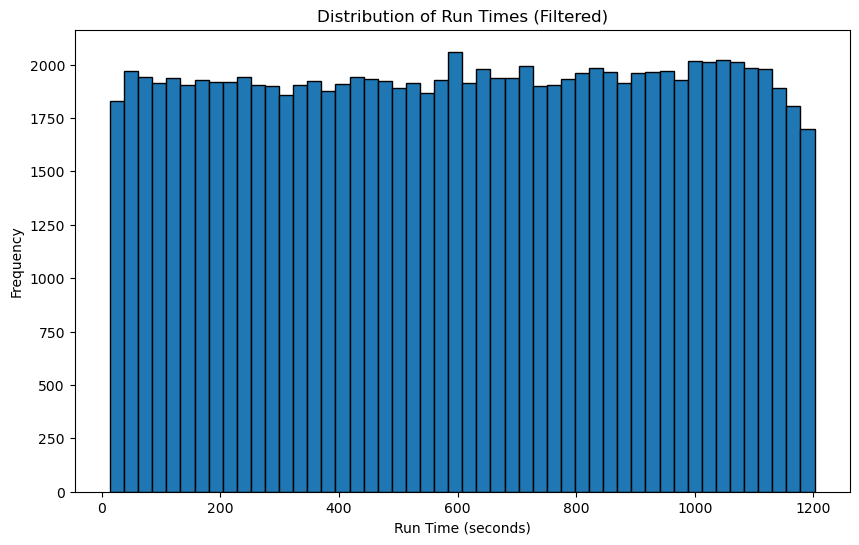

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(compiled_df["RunTime"], bins=50, edgecolor='black')
plt.title("Distribution of Run Times (Filtered)")
plt.xlabel("Run Time (seconds)")
plt.ylabel("Frequency")
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/Fixed/JataFixedFilteredRunTimezDistrib.png")
plt.show()

KS statistic: 0.004669956148501853
p-value: 0.02961040719119601


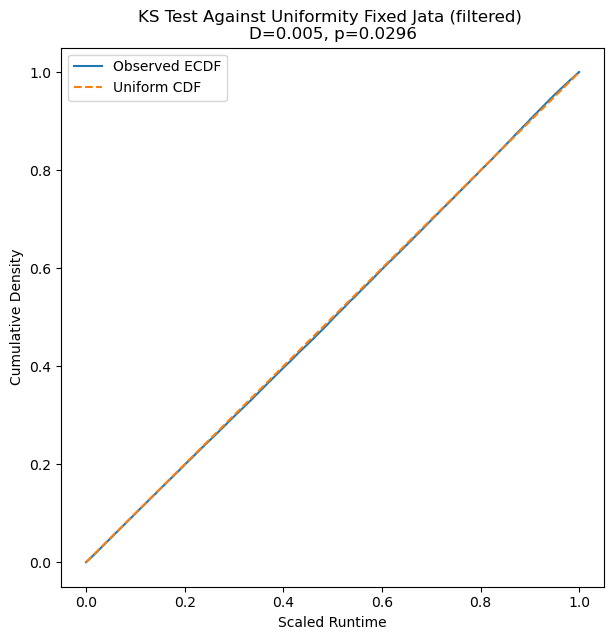

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(compiled_df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Fixed Jata (filtered) \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/Fixed/KSJataFixed.png", dpi=300)

plt.show()

In [44]:
## are they the same as the live cells can I use a ttest

# -----------------------------
# User inputs
# -----------------------------

data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/jatafixed/merged")

runtime_col = "RunTime"
file_pattern = "*.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
all_runtimes = []

for file in data_dir.glob(file_pattern):
    try:
        df = pd.read_csv(file, usecols=[runtime_col])

        # Convert to numeric and drop bad values
        runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

        all_runtimes.append(runtimes)

        print(f"Loaded {file.name}: {len(runtimes)} values")

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

# -----------------------------
# Combine into one Series
# -----------------------------
if all_runtimes:
    runtime_series = pd.concat(all_runtimes, ignore_index=True)
else:
    raise ValueError("No valid RunTime data found.")

print(f"\nTotal RunTime values: {len(runtime_series)}")
runtime_fixed = runtime_series

Loaded D20260603T192533_IFCB124_adc_only.csv: 5981 values
Loaded D20260603T224311_IFCB124_adc_only.csv: 4424 values
Loaded D20260604T025829_IFCB124_adc_only.csv: 3987 values
Loaded D20260604T003915_IFCB124_adc_only.csv: 4688 values
Loaded D20260604T012540_IFCB124_adc_only.csv: 4395 values
Loaded D20260604T010227_IFCB124_adc_only.csv: 4614 values
Loaded D20260603T183908_IFCB124_adc_only.csv: 6492 values
Loaded D20260603T232937_IFCB124_adc_only.csv: 5756 values
Loaded D20260603T221959_IFCB124_adc_only.csv: 5164 values
Loaded D20260603T215647_IFCB124_adc_only.csv: 5218 values
Loaded D20260604T023516_IFCB124_adc_only.csv: 3993 values
Loaded D20260604T014852_IFCB124_adc_only.csv: 4334 values
Loaded D20260603T181555_IFCB124_adc_only.csv: 6860 values
Loaded D20260603T204708_IFCB124_adc_only.csv: 5611 values
Loaded D20260604T021204_IFCB124_adc_only.csv: 4093 values
Loaded D20260603T235250_IFCB124_adc_only.csv: 5125 values
Loaded D20260603T230624_IFCB124_adc_only.csv: 4008 values
Loaded D202606

In [45]:
# -----------------------------
# User inputs
# -----------------------------

data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/hablab_jata_highV/merged")

runtime_col = "RunTime"
file_pattern = "*.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
all_runtimes = []

for file in data_dir.glob(file_pattern):
    try:
        df = pd.read_csv(file, usecols=[runtime_col])

        # Convert to numeric and drop bad values
        runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

        all_runtimes.append(runtimes)

        print(f"Loaded {file.name}: {len(runtimes)} values")

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

# -----------------------------
# Combine into one Series
# -----------------------------
if all_runtimes:
    runtime_series = pd.concat(all_runtimes, ignore_index=True)
else:
    raise ValueError("No valid RunTime data found.")

print(f"\nTotal RunTime values: {len(runtime_series)}")
runtime_live = runtime_series

Loaded D20260124T052534_IFCB124_adc_only.csv: 9960 values
Loaded D20260124T095039_IFCB149_adc_only.csv: 10053 values
Loaded D20260124T081741_IFCB149_adc_only.csv: 10038 values
Loaded D20260124T042517_IFCB149_adc_only.csv: 9900 values
Loaded D20260124T200739_IFCB124_adc_only.csv: 10196 values
Loaded D20260124T195454_IFCB149_adc_only.csv: 10274 values
Loaded D20260124T173529_IFCB149_adc_only.csv: 10331 values
Loaded D20260124T011921_IFCB149_adc_only.csv: 9841 values
Loaded D20260124T100409_IFCB124_adc_only.csv: 10008 values
Loaded D20260124T083118_IFCB124_adc_only.csv: 9973 values
Loaded D20260124T212752_IFCB149_adc_only.csv: 10268 values
Loaded D20260124T061200_IFCB124_adc_only.csv: 9856 values
Loaded D20260124T160231_IFCB149_adc_only.csv: 10294 values
Loaded D20260124T065825_IFCB124_adc_only.csv: 9934 values
Loaded D20260124T183448_IFCB124_adc_only.csv: 10258 values
Loaded D20260124T170157_IFCB124_adc_only.csv: 10420 values
Loaded D20260124T190825_IFCB149_adc_only.csv: 10305 values
Loa

In [46]:
from scipy.stats import ks_2samp

ks_stat, p_value = ks_2samp(runtime_fixed, runtime_live)

print(ks_stat, p_value)

0.0072767780543859795 4.002579210178369e-05


In [48]:
from scipy.stats import anderson_ksamp

result = anderson_ksamp([runtime_fixed, runtime_live])

print(result.statistic)
print(result.significance_level)

14.04387643021745
0.001


/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_72095/3061112037.py:3: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  result = anderson_ksamp([runtime_fixed, runtime_live])


## Grouping might be inflating P value instead compute each ks stat and then compare thoes between groups

In [52]:
# -----------------------------
# User inputs
# -----------------------------

data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/hablab_jata_highV/merged")

runtime_col = "RunTime"
file_pattern = "*.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
filename = []
result_p = []
result_stat = []
for file in data_dir.glob(file_pattern):

    df = pd.read_csv(file, usecols=[runtime_col])

    # Convert to numeric and drop bad values
    runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

    runtimes_norm = runtimes / runtimes.max()

    D, p = kstest(runtimes_norm, "uniform")
    filename.append(file.name)
    result_p.append(p)
    result_stat.append(D)



# ----------------------------
## Make DF

df_results_live = pd.DataFrame({
    "Kolmogorov-Smirnov Statistic": result_stat,
    "P-Value": result_p,
    "Filename": filename
})

### Do it again!


# -----------------------------
# User inputs
# -----------------------------

data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/jataFixed/merged")

runtime_col = "RunTime"
file_pattern = "*.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
filename = []
result_p = []
result_stat = []
for file in data_dir.glob(file_pattern):

    df = pd.read_csv(file, usecols=[runtime_col])

    # Convert to numeric and drop bad values
    runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

    runtimes_norm = runtimes / runtimes.max()

    D, p = kstest(runtimes_norm, "uniform")
    filename.append(file.name)
    result_p.append(p)
    result_stat.append(D)



# ----------------------------
## Make DF

df_results_fixed = pd.DataFrame({
    "Kolmogorov-Smirnov Statistic": result_stat,
    "P-Value": result_p,
    "Filename": filename
})

In [54]:
from scipy.stats import mannwhitneyu

U, p = mannwhitneyu(df_results_live["Kolmogorov-Smirnov Statistic"], df_results_fixed["Kolmogorov-Smirnov Statistic"])
print(U, p)

45.0 3.233766906567359e-11


## So they are not different or they are differnt but very small the larger the U stat the more similar the two groups are there are just a lot of samples

In [6]:
print(compiled_df.head())
files = list(data_dir.glob(file_pattern))
print(f"Files processed: {[file.name for file in files]}")

   trigger#  RoiNumber      PMTB    ADCtime    RunTime  InhibitTime  \
0         2          2  0.053962  13.930572  13.953166     0.073581   
1         3          3  0.005478  14.111737  14.134870     0.160532   
2         5          5  0.005080  14.384296  14.406997     0.331393   
3         6          6  0.010838  14.482679  14.506007     0.420647   
4         7          7  0.015280  14.591199  14.611977     0.504470   

   InhibitTimeDiff  VolumeAnalyzed  RoiType  RoiHeight  RoiWidth  RoiX  RoiY  \
0         0.073581        0.057832        1         44        72   924   366   
1         0.086951        0.058226        1         44        72   932   158   
2         0.086139        0.058648        1         52        72   924   582   
3         0.089253        0.058689        1         52        72   948   302   
4         0.083824        0.058781        1         52        72   908   782   

   RoiArea                            source_file  
0     3168  D20260603T192533_IFCB124_adc

In [7]:
results = []

for file in files:
    df = compiled_df[compiled_df["source_file"] == file.name]
    length = len(df)
    vol = max(df["VolumeAnalyzed"])
    roi_per_ml = length / vol if vol > 0 else 0
    results.append({
        "file": file.name,
        "ROIs": length,
        "volume_analyzed": vol,
        "roi_per_ml": roi_per_ml
    })

In [12]:
results_df = pd.DataFrame(results)
print(results_df)


                                     file  ROIs  volume_analyzed   roi_per_ml
0   D20260603T192533_IFCB124_adc_only.csv  4712         2.902436  1623.464090
1   D20260603T224311_IFCB124_adc_only.csv  3319         3.423448   969.490473
2   D20260604T025829_IFCB124_adc_only.csv  3332         3.569985   933.337305
3   D20260604T003915_IFCB124_adc_only.csv  3557         3.323658  1070.206339
4   D20260604T012540_IFCB124_adc_only.csv  3533         3.427936  1030.649462
5   D20260604T010227_IFCB124_adc_only.csv  3595         3.350876  1072.853688
6   D20260603T183908_IFCB124_adc_only.csv  5351         2.713271  1972.158029
7   D20260603T232937_IFCB124_adc_only.csv  3692         2.994566  1232.900049
8   D20260603T221959_IFCB124_adc_only.csv  3497         3.178675  1100.143758
9   D20260603T215647_IFCB124_adc_only.csv  3586         3.161792  1134.166917
10  D20260604T023516_IFCB124_adc_only.csv  3357         3.571347   939.981411
11  D20260604T014852_IFCB124_adc_only.csv  3457         3.434273

In [15]:
results_df["timestamp_str"] = results_df["file"].str.split("_").str[0]
results_df["timestamp"] = pd.to_datetime(results_df["timestamp_str"],format="D%Y%m%dT%H%M%S")
print(results_df.columns.tolist())

['file', 'ROIs', 'volume_analyzed', 'roi_per_ml', 'timestamp_str', 'timestamp']


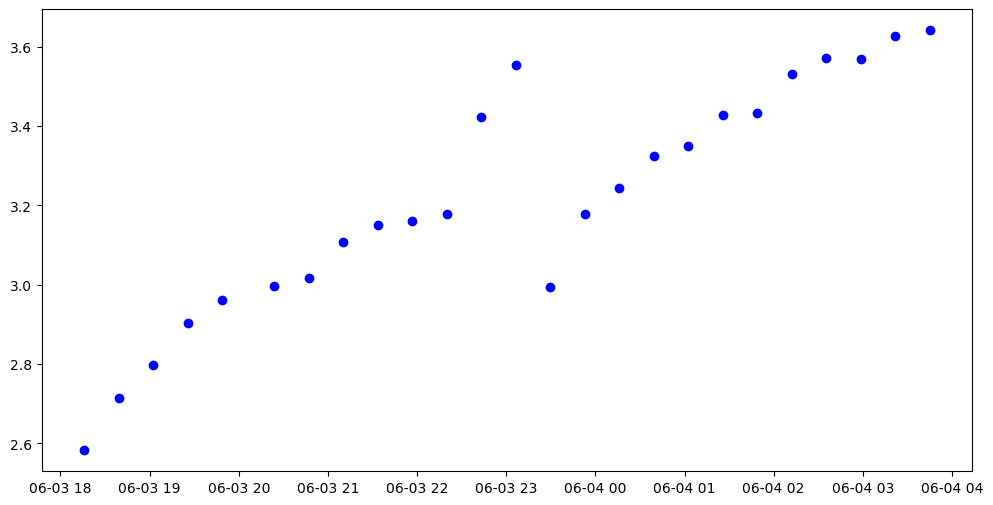

In [38]:
plt.figure(figsize=(12, 6))
plt.scatter(results_df["timestamp"], results_df["volume_analyzed"], color='blue')

In [19]:
print(compiled_df.columns.tolist())

['trigger#', 'RoiNumber', 'PMTB', 'ADCtime', 'RunTime', 'InhibitTime', 'InhibitTimeDiff', 'VolumeAnalyzed', 'RoiType', 'RoiHeight', 'RoiWidth', 'RoiX', 'RoiY', 'RoiArea', 'source_file']


                                    file  meanPMTB  medianPMTB  \
0  D20260603T192533_IFCB124_adc_only.csv  0.017262    0.013904   
1  D20260603T224311_IFCB124_adc_only.csv  0.019573    0.015143   
2  D20260604T025829_IFCB124_adc_only.csv  0.020016    0.015520   
3  D20260604T003915_IFCB124_adc_only.csv  0.019788    0.015187   
4  D20260604T012540_IFCB124_adc_only.csv  0.020127    0.015571   

            timestamp  
0 2026-06-03 19:25:33  
1 2026-06-03 22:43:11  
2 2026-06-04 02:58:29  
3 2026-06-04 00:39:15  
4 2026-06-04 01:25:40  


(array([20607.75      , 20607.79166667, 20607.83333333, 20607.875     ,
        20607.91666667, 20607.95833333, 20608.        , 20608.04166667,
        20608.08333333, 20608.125     , 20608.16666667]),
 [Text(20607.75, 0, '06-03 18'),
  Text(20607.791666666668, 0, '06-03 19'),
  Text(20607.833333333332, 0, '06-03 20'),
  Text(20607.875, 0, '06-03 21'),
  Text(20607.916666666668, 0, '06-03 22'),
  Text(20607.958333333332, 0, '06-03 23'),
  Text(20608.0, 0, '06-04 00'),
  Text(20608.041666666668, 0, '06-04 01'),
  Text(20608.083333333332, 0, '06-04 02'),
  Text(20608.125, 0, '06-04 03'),
  Text(20608.166666666668, 0, '06-04 04')])

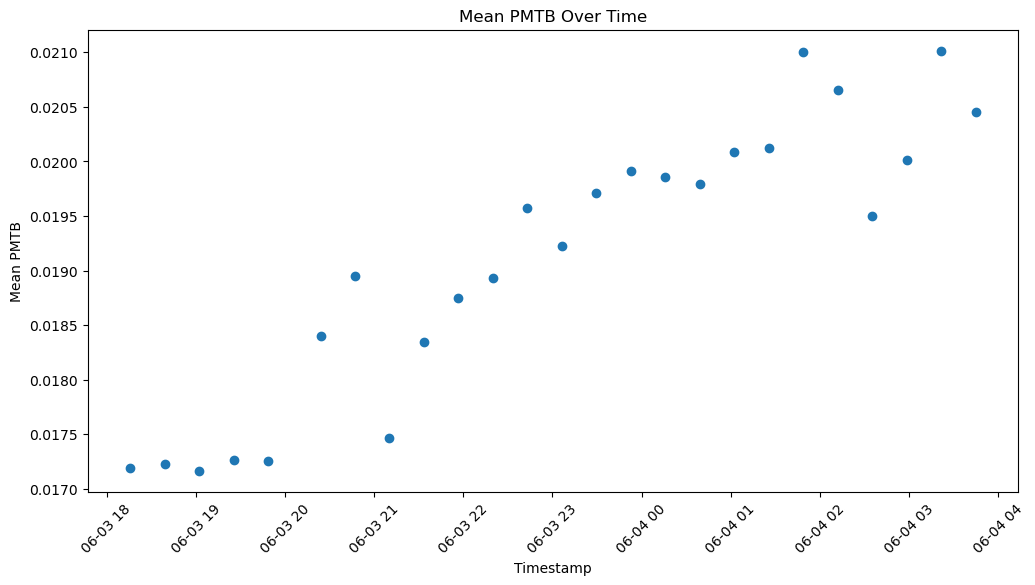

In [39]:
results = []

for file in files:
    df = compiled_df[compiled_df["source_file"] == file.name]
    meanpmtB = np.mean(df["PMTB"])
    medianpmtB = np.median(df["PMTB"])
    timestamp_str = file.name.split("_")[0]
    timestamp = pd.to_datetime(timestamp_str, format="D%Y%m%dT%H%M%S")
    results.append({
        "file": file.name,
        "meanPMTB": meanpmtB,
        "medianPMTB": medianpmtB,
        "timestamp": timestamp
    })

pmt_df = pd.DataFrame(results)
print(pmt_df.head())

plt.figure(figsize=(12, 6))
plt.scatter(pmt_df["timestamp"], pmt_df["meanPMTB"])
#plt.scatter(pmt_df["timestamp"], pmt_df["medianPMTB"], color='orange')
plt.xlabel("Timestamp")
plt.ylabel("Mean PMTB")
plt.title("Mean PMTB Over Time")
plt.xticks(rotation=45)


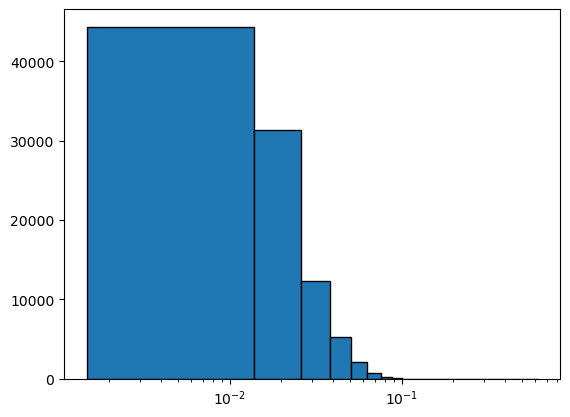

In [32]:
plt.hist(compiled_df["PMTB"], bins=50, edgecolor='black')
plt.xscale("log")